# Avaliação e comparação — baseline × BERTimbau (Fase 5)

Aqui **não treinamos nada**. O BERTimbau já está treinado e salvo em `modelo_bertimbau/`;
este notebook só o **recarrega** e roda a *inferência* no teste (rápido). Produz os 4
entregáveis pedidos:

1. **Tabela comparativa** de macro-F1 (baseline × BERTimbau).
2. **Matriz de confusão** mostrando quais temas o modelo troca por quais.
3. **Discussão do desbalanceamento** (cauda longa).
4. **3–4 ementas** classificadas certo/errado.

As saídas (tabela em CSV + figuras PNG) são salvas em disco para irem direto aos **slides**.

> **Pré-requisitos** (já existem na pasta): `modelo_bertimbau/`, `proposicoes_temas.csv`,
> `particao_treino_val_teste.csv`, `resultados_baseline.csv`, `resultados_bertimbau.csv`.
>
> Instale (uma vez): `pip install torch transformers scikit-learn pandas matplotlib`

## Passo 1 — Carregar dados, a divisão e os rótulos (multi-hot)
Mesma base e mesmo split das fases anteriores. `Y` é a tabela de 0/1 (32 temas).

In [ ]:
import os
os.makedirs("dados", exist_ok=True)
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

dados = pd.read_csv("dados/proposicoes_temas.csv")
dados["ementa"] = dados["ementa"].fillna("").astype(str)
particao = pd.read_csv("dados/particao_treino_val_teste.csv")
dados = dados.merge(particao, on="id")

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(dados["temas"].str.split("|"))
nomes_temas = list(mlb.classes_)
mask_sup200 = Y.sum(axis=0) >= 200

def separar(parte):
    m = (dados["particao"] == parte).values
    return dados.loc[m, "ementa"].tolist(), Y[m], np.where(m)[0]

textos_tr,  Y_tr,  idx_tr  = separar("treino")
textos_val, Y_val, idx_val = separar("validacao")
textos_te,  Y_te,  idx_te  = separar("teste")
print(f"treino: {len(textos_tr)} | validacao: {len(textos_val)} | teste: {len(textos_te)}")
print(f"temas com suporte >=200: {mask_sup200.sum()} de {len(nomes_temas)}")

treino: 13556 | validacao: 2907 | teste: 2891
temas com suporte >=200: 28 de 32


## Passo 2 — Recarregar o BERTimbau salvo e prever no teste (sem treinar)
Carregamos o modelo da pasta `modelo_bertimbau/` e usamos só para **prever**. Reutilizamos
a mesma preparação de dados (`max_length=192`) e a mesma função de limiar por tema das fases
anteriores.

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

MAX_LENGTH = 192
tokenizer = AutoTokenizer.from_pretrained("modelo_bertimbau")
modelo = AutoModelForSequenceClassification.from_pretrained("modelo_bertimbau")
print("GPU disponivel:", torch.cuda.is_available(), "| modelo recarregado de modelo_bertimbau/")

class DatasetEmentas(torch.utils.data.Dataset):
    def __init__(self, textos, rotulos):
        self.enc = tokenizer(textos, truncation=True, padding="max_length", max_length=MAX_LENGTH)
        self.rotulos = rotulos.astype("float32")
    def __len__(self):
        return len(self.rotulos)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.rotulos[i])
        return item

ds_val = DatasetEmentas(textos_val, Y_val)
ds_te  = DatasetEmentas(textos_te,  Y_te)

args = TrainingArguments(output_dir="bert_eval_tmp", per_device_eval_batch_size=32,
                         report_to="none", fp16=torch.cuda.is_available())
trainer = Trainer(model=modelo, args=args)

c:\Users\gutob\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4472.77it/s]


GPU disponivel: True | modelo recarregado de modelo_bertimbau/


In [ ]:
from sklearn.metrics import f1_score

def sigmoide(x):
    return 1 / (1 + np.exp(-x))

def probabilidades(ds):
    pred = trainer.predict(ds)
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    return sigmoide(logits)

def melhores_limiares(y_val, prob_val, grade=np.arange(0.05, 0.96, 0.05)):
    ts = []
    for j in range(y_val.shape[1]):
        f1s = [f1_score(y_val[:, j], (prob_val[:, j] >= t).astype(int), zero_division=0)
               for t in grade]
        ts.append(grade[int(np.argmax(f1s))] if max(f1s) > 0 else 0.5)
    return np.array(ts)

prob_val_bert   = probabilidades(ds_val)
prob_teste_bert = probabilidades(ds_te)
limiares_bert   = melhores_limiares(Y_val.astype(int), prob_val_bert)

pred_bert_05 = (prob_teste_bert >= 0.5).astype(int)
pred_bert_aj = (prob_teste_bert >= limiares_bert).astype(int)
print("Previsoes do BERTimbau no teste prontas.")

Previsoes do BERTimbau no teste prontas.


## Passo 3 — Re-treinar o baseline (rápido) para previsões no mesmo teste
O baseline (TF-IDF + Regressão Logística) treina em segundos. Refazemos só para ter as
**previsões alinhadas** no mesmo teste (necessário para o micro-F1 agregado, a matriz de
confusão e os exemplos do baseline). Mesmo protocolo de limiar por tema.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

vectorizer = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
Xtr  = vectorizer.fit_transform(textos_tr)
Xval = vectorizer.transform(textos_val)
Xte  = vectorizer.transform(textos_te)

base = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"))
base.fit(Xtr, Y_tr)

prob_val_base   = base.predict_proba(Xval)
prob_teste_base = base.predict_proba(Xte)
limiares_base   = melhores_limiares(Y_val.astype(int), prob_val_base)

pred_base_05 = (prob_teste_base >= 0.5).astype(int)
pred_base_aj = (prob_teste_base >= limiares_base).astype(int)
print("Previsoes do baseline no teste prontas.")

Previsoes do baseline no teste prontas.


## Passo 4 — Entregável 1: tabela comparativa (macro-F1 e micro-F1)
Mesmas métricas para os dois modelos, no limiar fixo 0,50 e no **limiar ajustado por tema**.
`macro(32)` = média do F1 nos 32 temas; `macro(≥200)` = só nos temas com suporte suficiente
(número mais justo); `micro` = agrega todos os acertos.

In [ ]:
y_true = Y_te.astype(int)

def tripla(y_pred):
    return {
        "macro_f1_32":     round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "macro_f1_sup200": round(f1_score(y_true[:, mask_sup200], y_pred[:, mask_sup200],
                                          average="macro", zero_division=0), 3),
        "micro_f1":        round(f1_score(y_true, y_pred, average="micro", zero_division=0), 3),
    }

tabela = pd.DataFrame([
    {"modelo": "baseline (0,50)",      **tripla(pred_base_05)},
    {"modelo": "baseline (ajustado)",  **tripla(pred_base_aj)},
    {"modelo": "BERTimbau (0,50)",     **tripla(pred_bert_05)},
    {"modelo": "BERTimbau (ajustado)", **tripla(pred_bert_aj)},
])
tabela.to_csv("dados/tabela_comparativa.csv", index=False, encoding="utf-8")
print("Salvo: dados/tabela_comparativa.csv\n")
tabela

Salvo: tabela_comparativa.csv



,modelo,macro_f1_32,macro_f1_sup200,micro_f1
0,"baseline (0,50)",0.567,0.620,0.650
1,baseline (ajustado),0.584,0.639,0.675
2,"BERTimbau (0,50)",0.601,0.687,0.724
3,BERTimbau (ajustado),0.632,0.700,0.723


### Ganho por tema (BERTimbau − baseline), ambos com limiar ajustado
Usa os `resultados_*.csv` já salvos (F1 por tema). Mostra onde o BERTimbau mais ajuda.

In [ ]:
rb = pd.read_csv("dados/resultados_bertimbau.csv")[["tema", "f1", "suporte_teste"]]
rb = rb.rename(columns={"f1": "f1_bertimbau"})
ra = pd.read_csv("dados/resultados_baseline.csv")[["tema", "f1"]].rename(columns={"f1": "f1_baseline"})
ganho = rb.merge(ra, on="tema")
ganho["ganho"] = (ganho["f1_bertimbau"] - ganho["f1_baseline"]).round(3)
ganho = ganho.sort_values("ganho", ascending=False)[
    ["tema", "suporte_teste", "f1_baseline", "f1_bertimbau", "ganho"]]
ganho

,tema,suporte_teste,f1_baseline,f1_bertimbau,ganho
8,"Arte, Cultura e Religião",149,0.590476,0.785479,0.195
28,Direito e Justiça,98,0.202703,0.363636,0.161
2,Esporte e Lazer,114,0.716981,0.859813,0.143
20,Estrutura Fundiária,37,0.500000,0.628571,0.129
6,Meio Ambiente e Desenvolvimento Sustentável,274,0.712430,0.816176,0.104
25,Economia,189,0.463612,0.534737,0.071
15,Previdência e Assistência Social,164,0.626667,0.695652,0.069
7,"Política, Partidos e Eleições",40,0.727273,0.795181,0.068
19,"Agricultura, Pecuária, Pesca e Extrativismo",116,0.568889,0.637255,0.068
4,Saúde,542,0.766320,0.833819,0.067


## Passo 5 — Entregável 2: matriz de confusão (multirrótulo, BERTimbau)

Em multirrótulo não existe a matriz de confusão clássica (cada proposição tem vários temas).
Montamos a versão que responde **"quais temas o modelo troca por quais"**:

`M[i, j]` = nº de proposições do teste cujo tema verdadeiro inclui **i** e em que o modelo
**previu** o tema **j**. Normalizando por linha: dado que a verdade é o tema *i*, qual a
fração de vezes que o modelo aciona o tema *j*. A **diagonal** é acerto; o que está **fora
da diagonal** são as **confusões** (ex.: prever *Economia* quando era *Finanças Públicas*).

Para a figura ficar legível, usamos os 28 temas com suporte ≥200, ordenados por suporte.

In [ ]:
# matriz verdadeiro x previsto (com limiar ajustado do BERTimbau)
n = len(nomes_temas)
M = np.zeros((n, n), dtype=int)
for vt, vp in zip(y_true, pred_bert_aj):
    ti = np.where(vt == 1)[0]
    pj = np.where(vp == 1)[0]
    for i in ti:
        for j in pj:
            M[i, j] += 1

# normaliza por linha (evita divisao por zero)
linha = M.sum(axis=1, keepdims=True)
Mn = np.divide(M, linha, out=np.zeros_like(M, dtype=float), where=linha > 0)

# subconjunto >=200, ordenado por suporte (desc)
sup_total = Y.sum(axis=0)
idx200 = [i for i in np.argsort(-sup_total) if mask_sup200[i]]
rotulos = [nomes_temas[i][:22] for i in idx200]
Msub = Mn[np.ix_(idx200, idx200)]

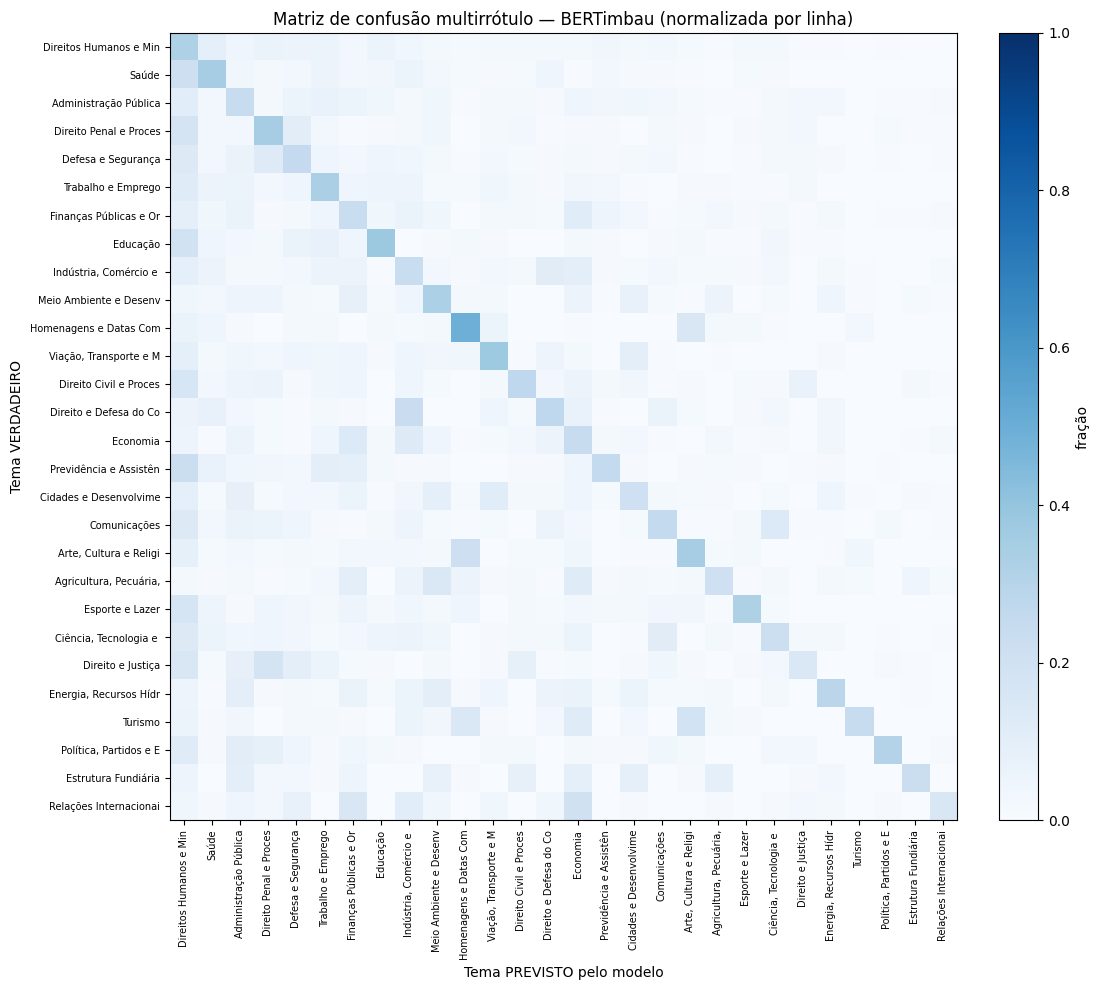

Salvo: figuras/matriz_confusao_bertimbau.png


In [ ]:
import matplotlib.pyplot as plt
import os
os.makedirs("figuras", exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(Msub, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(rotulos))); ax.set_xticklabels(rotulos, rotation=90, fontsize=7)
ax.set_yticks(range(len(rotulos))); ax.set_yticklabels(rotulos, fontsize=7)
ax.set_xlabel("Tema PREVISTO pelo modelo"); ax.set_ylabel("Tema VERDADEIRO")
ax.set_title("Matriz de confusão multirrótulo — BERTimbau (normalizada por linha)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fração")
plt.tight_layout()
plt.savefig("figuras/matriz_confusao_bertimbau.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: figuras/matriz_confusao_bertimbau.png")

**Maiores confusões** (fora da diagonal): pares (tema verdadeiro → tema previsto) com
maior fração. É aqui que aparecem os temas semanticamente vizinhos.

In [ ]:
pares = []
for a in range(n):
    for b in range(n):
        if a != b and M[a].sum() >= 30:   # so temas verdadeiros com volume razoavel
            pares.append((nomes_temas[a], nomes_temas[b], Mn[a, b], M[a, b]))
pares = sorted(pares, key=lambda x: x[2], reverse=True)[:10]
print("verdadeiro  ->  previsto   (fracao | n)")
for a, b, frac, cnt in pares:
    print(f"  {a[:30]:<32} -> {b[:30]:<32} {frac:.2f} | {cnt}")

verdadeiro  ->  previsto   (fracao | n)
  Direito e Defesa do Consumidor   -> Indústria, Comércio e Serviços   0.23 | 122
  Previdência e Assistência Soci   -> Direitos Humanos e Minorias      0.22 | 96
  Arte, Cultura e Religião         -> Homenagens e Datas Comemorativ   0.21 | 72
  Saúde                            -> Direitos Humanos e Minorias      0.21 | 260
  Relações Internacionais e Comé   -> Economia                         0.20 | 22
  Educação                         -> Direitos Humanos e Minorias      0.19 | 129
  Turismo                          -> Arte, Cultura e Religião         0.19 | 22
  Processo Legislativo e Atuação   -> Administração Pública            0.18 | 8
  Direito Penal e Processual Pen   -> Direitos Humanos e Minorias      0.18 | 177
  Direito e Justiça                -> Direito Penal e Processual Pen   0.18 | 42


## Passo 6 — Entregável 3: discussão do desbalanceamento (cauda longa)
A dificuldade principal não é desbalanceamento single-label, e sim a **cauda longa**: alguns
temas têm pouquíssimos exemplos e por isso F1≈0 (esperado e documentado). O gráfico mostra o
suporte por tema; a tabela cruza suporte × F1.

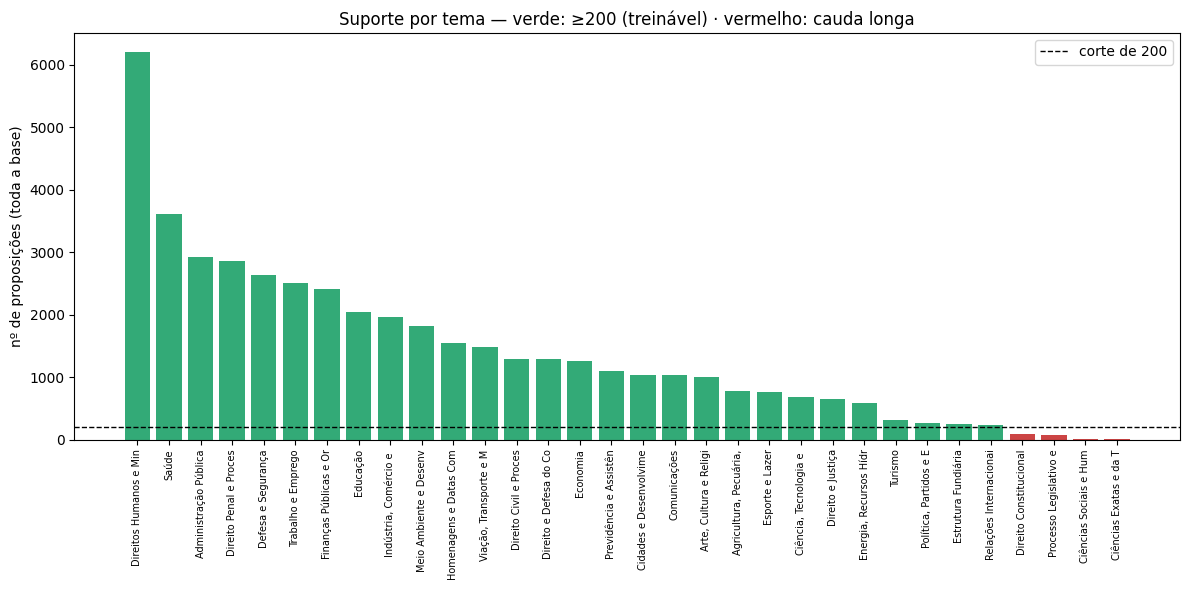

Salvo: figuras/suporte_por_tema.png


In [ ]:
ordem = np.argsort(-sup_total)
fig, ax = plt.subplots(figsize=(12, 6))
cores = ["#3a7" if mask_sup200[i] else "#c44" for i in ordem]
ax.bar(range(n), sup_total[ordem], color=cores)
ax.axhline(200, color="black", ls="--", lw=1, label="corte de 200")
ax.set_xticks(range(n)); ax.set_xticklabels([nomes_temas[i][:22] for i in ordem],
                                            rotation=90, fontsize=7)
ax.set_ylabel("nº de proposições (toda a base)")
ax.set_title("Suporte por tema — verde: ≥200 (treinável) · vermelho: cauda longa")
ax.legend()
plt.tight_layout()
plt.savefig("figuras/suporte_por_tema.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: figuras/suporte_por_tema.png")

In [ ]:
# tabela suporte total x suporte no teste x F1 (BERTimbau), ordenada do menor suporte
tab_sup = pd.read_csv("dados/resultados_bertimbau.csv")[["tema", "f1", "suporte_teste"]]
sup_map = {nomes_temas[i]: int(sup_total[i]) for i in range(n)}
tab_sup["suporte_total"] = tab_sup["tema"].map(sup_map)
tab_sup = tab_sup.sort_values("suporte_total")[["tema", "suporte_total", "suporte_teste", "f1"]]
print("Cauda longa (menores suportes) — F1 do BERTimbau:")
tab_sup.head(8)

Cauda longa (menores suportes) — F1 do BERTimbau:


,tema,suporte_total,suporte_teste,f1
30,Ciências Exatas e da Terra,5,1,0.000000
31,Ciências Sociais e Humanas,11,2,0.000000
24,Processo Legislativo e Atuação Parlamentar,75,11,0.555556
29,Direito Constitucional,84,13,0.058824
27,Relações Internacionais e Comércio Exterior,237,36,0.492754
20,Estrutura Fundiária,247,37,0.628571
7,"Política, Partidos e Eleições",269,40,0.795181
14,Turismo,308,46,0.708861


## Passo 7 — Entregável 4: ementas classificadas certo/errado
Mostramos a ementa, os temas **verdadeiros** e os **previstos** pelo BERTimbau. Escolhemos
automaticamente 2 acertos (previsão idêntica à verdade) e 2 erros ilustrativos.

In [ ]:
def temas_de(linha_binaria):
    return [nomes_temas[i] for i in np.where(linha_binaria == 1)[0]]

def mostrar(pos_teste, titulo):
    g = idx_te[pos_teste]
    ementa = dados.iloc[g]["ementa"]
    reais = temas_de(y_true[pos_teste])
    prev  = temas_de(pred_bert_aj[pos_teste])
    print(f"\n[{titulo}]")
    print("Ementa:", (ementa[:230] + "...") if len(ementa) > 230 else ementa)
    print("  Temas REAIS....:", " | ".join(reais))
    print("  Temas PREVISTOS:", " | ".join(prev) if prev else "(nenhum)")
    return {"ementa": ementa, "temas_reais": "|".join(reais),
            "temas_previstos": "|".join(prev), "acertou": reais == prev}

# acertos exatos (com pelo menos 1 tema) e erros
acertos, erros = [], []
for k in range(len(y_true)):
    reais = set(np.where(y_true[k] == 1)[0]); prev = set(np.where(pred_bert_aj[k] == 1)[0])
    if reais and reais == prev:
        acertos.append(k)
    elif reais and reais != prev:
        erros.append(k)

linhas = []
for k in acertos[:2]:
    linhas.append(mostrar(k, "ACERTO"))
for k in erros[:2]:
    linhas.append(mostrar(k, "ERRO"))

pd.DataFrame(linhas).to_csv("dados/exemplos_classificacao.csv", index=False, encoding="utf-8")
print("\nSalvo: dados/exemplos_classificacao.csv")


[ACERTO]
Ementa: Dispõe sobre a prestação de serviços postais aos órgãos públicos federais da Administração Direta e Indireta, e dá outras providências.  NOVA EMENTA: Dispõe sobre a prestação de serviços postais aos órgãos públicos federais da adm...
  Temas REAIS....: Administração Pública | Comunicações
  Temas PREVISTOS: Administração Pública | Comunicações

[ACERTO]
Ementa: Inscreve o nome de Edson Arantes do Nascimento, o Pelé, no Livro dos Heróis e Heroínas da Pátria.
  Temas REAIS....: Homenagens e Datas Comemorativas
  Temas PREVISTOS: Homenagens e Datas Comemorativas

[ERRO]
Ementa: Altera a Lei nº 12.529, de 30 de novembro de 2011, para inserir nova infração concorrencial.
  Temas REAIS....: Economia | Finanças Públicas e Orçamento
  Temas PREVISTOS: Administração Pública | Comunicações | Política, Partidos e Eleições

[ERRO]
Ementa: Estabelece protocolo de segurança para as mulheres em casas de festas, discotecas, boates e bares, cria o Selo Não é Não – Mulheres Seguras e d

---
**Pronto.** Saídas geradas para os slides: `tabela_comparativa.csv`,
`figuras/matriz_confusao_bertimbau.png`, `figuras/suporte_por_tema.png` e
`exemplos_classificacao.csv`. A próxima fase (6) aplica este modelo aos **discursos
parlamentares** (estudo de *domain shift*).